# Stage 5A — Nexar 5-FPS Motion Analysis

This notebook is self-contained: Hugging Face authentication → select training videos → download → verify → 5 FPS sampling → Farneback optical flow → 14×14 DINOv2 patch motion vectors → CSV/JSON/NPZ outputs and visualization.

**It does not run DINOv2 yet.** The purpose is to establish motion-aware patch correspondence first.

In [ ]:
!pip install -q -U huggingface_hub
print("huggingface_hub ready.")

In [1]:
from kaggle_secrets import UserSecretsClient
from huggingface_hub import login, whoami

user_secrets = UserSecretsClient()
try:
    hf_token = user_secrets.get_secret("HF_TOKEN")
except Exception as e:
    raise RuntimeError(
        "Create a Kaggle Secret named HF_TOKEN containing your Hugging Face READ token."
    ) from e

if not hf_token:
    raise RuntimeError("HF_TOKEN is empty.")

login(token=hf_token)
print("Authenticated as:", whoami(token=hf_token)["name"])

Authenticated as: saanzi


In [2]:
from pathlib import Path

REPO_ID = "nexar-ai/nexar_collision_prediction"
REPO_TYPE = "dataset"

WORK_DIR = Path("/kaggle/working/nexar_stage5")
VIDEO_DIR = WORK_DIR / "videos"
OUTPUT_DIR = WORK_DIR / "motion"
VIDEO_DIR.mkdir(parents=True, exist_ok=True)
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

NUM_VIDEOS = 4
TARGET_FPS = 5.0
EXPECTED_SOURCE_FPS = 30.0

IMAGE_SIZE = 640
PATCH_SIZE = 14
GRID_SIZE = IMAGE_SIZE // PATCH_SIZE
NUM_PATCHES = GRID_SIZE * GRID_SIZE

MOTION_PIXEL_THRESHOLD = 1.0
SAVE_PATCH_FLOW = True
CREATE_VISUALIZATION = True
ARROW_STEP = 3

print("Repository:", REPO_ID)
print("Videos:", NUM_VIDEOS)
print("Target FPS:", TARGET_FPS)
print("DINO image space:", IMAGE_SIZE, "x", IMAGE_SIZE)
print("Patch grid:", GRID_SIZE, "x", GRID_SIZE)
print("Patch tokens:", NUM_PATCHES)

Repository: nexar-ai/nexar_collision_prediction
Videos: 4
Target FPS: 5.0
DINO image space: 640 x 640
Patch grid: 45 x 45
Patch tokens: 2025


In [3]:
from huggingface_hub import list_repo_files

files = list_repo_files(
    REPO_ID,
    repo_type=REPO_TYPE,
    token=hf_token
)
mp4s = [f for f in files if f.lower().endswith(".mp4")]

print("Total accessible MP4 files:", len(mp4s))
for f in mp4s[:20]:
    print(f)

Total accessible MP4 files: 2844
test-private/negative/01047.mp4
test-private/negative/01053.mp4
test-private/negative/01055.mp4
test-private/negative/01057.mp4
test-private/negative/01063.mp4
test-private/negative/01064.mp4
test-private/negative/01077.mp4
test-private/negative/01082.mp4
test-private/negative/01086.mp4
test-private/negative/01087.mp4
test-private/negative/01091.mp4
test-private/negative/01093.mp4
test-private/negative/01104.mp4
test-private/negative/01105.mp4
test-private/negative/01106.mp4
test-private/negative/01107.mp4
test-private/negative/01120.mp4
test-private/negative/01123.mp4
test-private/negative/01124.mp4
test-private/negative/01160.mp4


In [4]:
negative_train = sorted(
    f for f in mp4s
    if f.startswith("train/negative/")
)

if not negative_train:
    raise RuntimeError("No train/negative MP4 files found.")

SELECTED_VIDEOS = negative_train[:NUM_VIDEOS]

print("Available train/negative videos:", len(negative_train))
print("Selected:")
for f in SELECTED_VIDEOS:
    print(" ", f)

Available train/negative videos: 750
Selected:
  train/negative/01040.mp4
  train/negative/01041.mp4
  train/negative/01042.mp4
  train/negative/01043.mp4


In [5]:
from huggingface_hub import hf_hub_download

downloaded = []

for remote_path in SELECTED_VIDEOS:
    local_path = VIDEO_DIR / remote_path
    local_path.parent.mkdir(parents=True, exist_ok=True)

    if local_path.exists() and local_path.stat().st_size > 0:
        print("Already exists:", local_path)
        downloaded.append(str(local_path))
        continue

    print("Downloading:", remote_path)
    path = hf_hub_download(
        repo_id=REPO_ID,
        repo_type=REPO_TYPE,
        filename=remote_path,
        token=hf_token,
        local_dir=str(VIDEO_DIR)
    )
    downloaded.append(path)
    print("Saved:", path)

print("Videos available:", len(downloaded))

Downloading: train/negative/01040.mp4


train/negative/01040.mp4:   0%|          | 0.00/12.1M [00:00<?, ?B/s]

Saved: /kaggle/working/nexar_stage5/videos/train/negative/01040.mp4
Downloading: train/negative/01041.mp4


train/negative/01041.mp4:   0%|          | 0.00/28.4M [00:00<?, ?B/s]

Saved: /kaggle/working/nexar_stage5/videos/train/negative/01041.mp4
Downloading: train/negative/01042.mp4


train/negative/01042.mp4:   0%|          | 0.00/8.60M [00:00<?, ?B/s]

Saved: /kaggle/working/nexar_stage5/videos/train/negative/01042.mp4
Downloading: train/negative/01043.mp4


train/negative/01043.mp4:   0%|          | 0.00/24.6M [00:00<?, ?B/s]

Saved: /kaggle/working/nexar_stage5/videos/train/negative/01043.mp4
Videos available: 4


In [6]:
import cv2
import pandas as pd
from pathlib import Path

video_files = sorted(VIDEO_DIR.rglob("*.mp4"))
if not video_files:
    raise RuntimeError("No MP4 files found after download.")

video_info = []
for video_path in video_files:
    cap = cv2.VideoCapture(str(video_path))
    if not cap.isOpened():
        print("WARNING: cannot open", video_path)
        continue
    fps = float(cap.get(cv2.CAP_PROP_FPS))
    n = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    w = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
    h = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
    cap.release()
    video_info.append({
        "video": video_path.name,
        "path": str(video_path),
        "fps": fps,
        "frame_count": n,
        "width": w,
        "height": h,
        "duration_sec": n / fps if fps else 0
    })

video_info_df = pd.DataFrame(video_info)
display(video_info_df)

,video,path,fps,frame_count,width,height,duration_sec
0,01040.mp4,/kaggle/working/nexar_stage5/videos/train/nega...,30.0,1180,1280,720,39.333333
1,01041.mp4,/kaggle/working/nexar_stage5/videos/train/nega...,30.0,1183,1280,720,39.433333
2,01042.mp4,/kaggle/working/nexar_stage5/videos/train/nega...,30.0,540,1280,720,18.000000
3,01043.mp4,/kaggle/working/nexar_stage5/videos/train/nega...,30.0,1211,1280,720,40.366667


In [7]:
import numpy as np
from tqdm.auto import tqdm

def read_frame_at_index(cap, frame_index, image_size=640):
    cap.set(cv2.CAP_PROP_POS_FRAMES, int(frame_index))
    ok, frame = cap.read()
    if not ok:
        return None
    frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
    return cv2.resize(frame, (image_size, image_size), interpolation=cv2.INTER_LINEAR)

def compute_optical_flow(prev_rgb, curr_rgb):
    prev_gray = cv2.cvtColor(prev_rgb, cv2.COLOR_RGB2GRAY)
    curr_gray = cv2.cvtColor(curr_rgb, cv2.COLOR_RGB2GRAY)
    flow = cv2.calcOpticalFlowFarneback(
        prev_gray, curr_gray, None,
        pyr_scale=0.5, levels=3, winsize=15,
        iterations=3, poly_n=5, poly_sigma=1.2, flags=0
    )
    return flow.astype(np.float32)

def flow_to_patch_motion(flow):
    patch_flow = np.zeros((GRID_SIZE, GRID_SIZE, 2), dtype=np.float32)
    for r in range(GRID_SIZE):
        for c in range(GRID_SIZE):
            y0, y1 = r * PATCH_SIZE, (r + 1) * PATCH_SIZE
            x0, x1 = c * PATCH_SIZE, (c + 1) * PATCH_SIZE
            patch = flow[y0:y1, x0:x1]
            patch_flow[r, c] = np.median(patch.reshape(-1, 2), axis=0)
    return patch_flow

In [8]:
def process_video(video_path):
    cap = cv2.VideoCapture(str(video_path))
    if not cap.isOpened():
        raise RuntimeError(f"Could not open {video_path}")

    source_fps = float(cap.get(cv2.CAP_PROP_FPS))
    total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    stride = int(round(source_fps / TARGET_FPS))
    effective_fps = source_fps / stride

    sampled_indices = list(range(0, total_frames, stride))
    num_pairs = max(0, len(sampled_indices) - 1)

    print(f"\n{video_path.name}: {source_fps:.2f} FPS → {effective_fps:.2f} FPS; "
          f"{len(sampled_indices)} sampled frames; {num_pairs} pairs")

    records = []
    patch_flows = []
    visualization = None

    for i in tqdm(range(num_pairs), desc=video_path.stem):
        prev_idx = sampled_indices[i]
        curr_idx = sampled_indices[i + 1]

        prev = read_frame_at_index(cap, prev_idx, IMAGE_SIZE)
        curr = read_frame_at_index(cap, curr_idx, IMAGE_SIZE)
        if prev is None or curr is None:
            continue

        flow = compute_optical_flow(prev, curr)
        pf = flow_to_patch_motion(flow)

        dx, dy = pf[..., 0], pf[..., 1]
        mag = np.sqrt(dx * dx + dy * dy)
        moving = mag > MOTION_PIXEL_THRESHOLD

        records.append({
            "video": video_path.name,
            "pair_idx": i,
            "source_frame_prev": prev_idx,
            "source_frame_curr": curr_idx,
            "time_prev_sec": prev_idx / source_fps,
            "time_curr_sec": curr_idx / source_fps,
            "effective_fps": effective_fps,
            "mean_dx": float(dx.mean()),
            "mean_dy": float(dy.mean()),
            "mean_motion": float(mag.mean()),
            "median_motion": float(np.median(mag)),
            "max_motion": float(mag.max()),
            "moving_patch_fraction": float(moving.mean()),
            "moving_patch_percent": float(moving.mean() * 100)
        })

        if SAVE_PATCH_FLOW:
            patch_flows.append(pf)

        if CREATE_VISUALIZATION and visualization is None:
            visualization = {
                "previous_frame": prev,
                "current_frame": curr,
                "patch_flow": pf
            }

    cap.release()
    return pd.DataFrame(records), patch_flows, visualization

In [9]:
import time

all_records = []
all_patch_flows = {}
visualizations = {}

start = time.time()

for video_path in video_files:
    df, flows, vis = process_video(video_path)
    if len(df):
        all_records.append(df)
        all_patch_flows[video_path.name] = flows
        if vis is not None:
            visualizations[video_path.name] = vis

if not all_records:
    raise RuntimeError("No motion results generated.")

motion_df = pd.concat(all_records, ignore_index=True)
elapsed = time.time() - start

print("\nTotal pairs:", len(motion_df))
print("Runtime:", round(elapsed, 2), "sec")


01040.mp4: 30.00 FPS → 5.00 FPS; 197 sampled frames; 196 pairs


01040:   0%|          | 0/196 [00:00<?, ?it/s]


01041.mp4: 30.00 FPS → 5.00 FPS; 198 sampled frames; 197 pairs


01041:   0%|          | 0/197 [00:00<?, ?it/s]


01042.mp4: 30.00 FPS → 5.00 FPS; 90 sampled frames; 89 pairs


01042:   0%|          | 0/89 [00:00<?, ?it/s]


01043.mp4: 30.00 FPS → 5.00 FPS; 202 sampled frames; 201 pairs


01043:   0%|          | 0/201 [00:00<?, ?it/s]


Total pairs: 683
Runtime: 564.95 sec


In [10]:
# Save patch motion vectors
import json
if SAVE_PATCH_FLOW:
    arrays = {
        Path(name).stem: np.stack(flows, axis=0)
        for name, flows in all_patch_flows.items()
        if flows
    }
    patch_file = OUTPUT_DIR / "stage5_patch_motion_vectors.npz"
    np.savez_compressed(patch_file, **arrays)
    print("Saved:", patch_file)
    for name, arr in arrays.items():
        print(name, arr.shape, arr.dtype)

# Save pair-level CSV
summary_csv = OUTPUT_DIR / "stage5_motion_summary.csv"
motion_df.to_csv(summary_csv, index=False)

# Per-video summary
per_video = (
    motion_df.groupby("video")
    .agg(
        pairs=("pair_idx", "count"),
        mean_motion=("mean_motion", "mean"),
        median_motion=("median_motion", "median"),
        max_motion=("max_motion", "max"),
        mean_moving_patch_percent=("moving_patch_percent", "mean"),
        median_moving_patch_percent=("moving_patch_percent", "median")
    )
    .reset_index()
)
per_video_csv = OUTPUT_DIR / "stage5_motion_per_video.csv"
per_video.to_csv(per_video_csv, index=False)

overall = {
    "stage": "Stage 5A - 5 FPS Motion Analysis",
    "dataset": "Nexar Collision Prediction",
    "num_videos": len(video_files),
    "total_frame_pairs": int(len(motion_df)),
    "source_fps_expected": EXPECTED_SOURCE_FPS,
    "target_fps": TARGET_FPS,
    "image_size": IMAGE_SIZE,
    "patch_size": PATCH_SIZE,
    "patch_grid": [GRID_SIZE, GRID_SIZE],
    "num_patch_tokens": NUM_PATCHES,
    "motion_method": "Farneback dense optical flow",
    "patch_motion_method": "median pixel flow within each 14x14 patch",
    "motion_threshold_pixels": MOTION_PIXEL_THRESHOLD,
    "mean_motion": float(motion_df["mean_motion"].mean()),
    "median_motion": float(motion_df["median_motion"].median()),
    "max_motion": float(motion_df["max_motion"].max()),
    "mean_moving_patch_percent": float(motion_df["moving_patch_percent"].mean()),
    "median_moving_patch_percent": float(motion_df["moving_patch_percent"].median()),
    "runtime_seconds": float(elapsed)
}

with open(OUTPUT_DIR / "stage5_motion_summary.json", "w") as f:
    json.dump(overall, f, indent=2)

with open(OUTPUT_DIR / "stage5_motion_config.json", "w") as f:
    json.dump({
        "repo_id": REPO_ID,
        "selected_videos": SELECTED_VIDEOS,
        "source_fps": EXPECTED_SOURCE_FPS,
        "target_fps": TARGET_FPS,
        "image_size": IMAGE_SIZE,
        "patch_size": PATCH_SIZE,
        "grid_size": GRID_SIZE,
        "num_patches": NUM_PATCHES,
        "optical_flow": "Farneback",
        "note": "No DINOv2 token reuse or speedup is claimed in Stage 5A."
    }, f, indent=2)

print("Saved summaries to:", OUTPUT_DIR)

Saved: /kaggle/working/nexar_stage5/motion/stage5_patch_motion_vectors.npz
01040 (196, 45, 45, 2) float32
01041 (197, 45, 45, 2) float32
01042 (89, 45, 45, 2) float32
01043 (201, 45, 45, 2) float32
Saved summaries to: /kaggle/working/nexar_stage5/motion


In [11]:
print("=" * 70)
print("STAGE 5A COMPLETE")
print("=" * 70)
print("Videos:", len(video_files))
print("5-FPS frame pairs:", len(motion_df))
print("Mean patch motion:", round(motion_df["mean_motion"].mean(), 4), "px")
print("Median patch motion:", round(motion_df["median_motion"].median(), 4), "px")
print("Max patch motion:", round(motion_df["max_motion"].max(), 4), "px")
print("Mean moving patches:", round(motion_df["moving_patch_percent"].mean(), 2), "%")
print("Median moving patches:", round(motion_df["moving_patch_percent"].median(), 2), "%")
print("Runtime:", round(elapsed, 2), "sec")

print("\nPer-video:")
display(per_video)

print("\nFirst 10 pairs:")
display(motion_df.head(10))

STAGE 5A COMPLETE
Videos: 4
5-FPS frame pairs: 683
Mean patch motion: 3.8846 px
Median patch motion: 0.1359 px
Max patch motion: 169.7448 px
Mean moving patches: 36.24 %
Median moving patches: 37.98 %
Runtime: 564.95 sec

Per-video:


,video,pairs,mean_motion,median_motion,max_motion,mean_moving_patch_percent,median_moving_patch_percent
0,01040.mp4,196,1.612067,0.014988,102.972160,19.931469,24.962963
1,01041.mp4,197,6.025444,3.846306,96.358208,60.399323,62.370370
2,01042.mp4,89,0.915193,0.007375,169.744751,12.192537,12.444444
3,01043.mp4,201,5.317310,0.242164,145.737213,39.106443,43.851852



First 10 pairs:


,video,pair_idx,source_frame_prev,source_frame_curr,time_prev_sec,time_curr_sec,effective_fps,mean_dx,mean_dy,mean_motion,median_motion,max_motion,moving_patch_fraction,moving_patch_percent
0,01040.mp4,0,0,6,0.0,0.2,5.0,-0.018085,0.000897,0.046651,0.016523,1.917977,0.004444,0.444444
1,01040.mp4,1,6,12,0.2,0.4,5.0,-0.015469,0.002747,0.058909,0.020322,1.736968,0.002963,0.296296
2,01040.mp4,2,12,18,0.4,0.6,5.0,-0.012470,-0.000413,0.075202,0.025865,1.671723,0.005926,0.592593
3,01040.mp4,3,18,24,0.6,0.8,5.0,-0.022357,0.004410,0.060998,0.022422,1.368979,0.002963,0.296296
4,01040.mp4,4,24,30,0.8,1.0,5.0,-0.015340,-0.005015,0.069167,0.019059,6.610642,0.003457,0.345679
5,01040.mp4,5,30,36,1.0,1.2,5.0,-0.033232,-0.000189,0.073928,0.022863,1.314287,0.001481,0.148148
6,01040.mp4,6,36,42,1.2,1.4,5.0,-0.046909,0.011169,0.093582,0.023243,1.296306,0.004444,0.444444
7,01040.mp4,7,42,48,1.4,1.6,5.0,-0.067620,-0.010506,0.135396,0.021518,2.022383,0.045432,4.543210
8,01040.mp4,8,48,54,1.6,1.8,5.0,-0.098241,-0.017147,0.217451,0.027449,3.936282,0.085432,8.543210
9,01040.mp4,9,54,60,1.8,2.0,5.0,-0.126497,-0.042977,0.289060,0.028672,4.103852,0.093333,9.333333


Visualization saved: /kaggle/working/nexar_stage5/motion/stage5_motion_visualization_01040.jpg


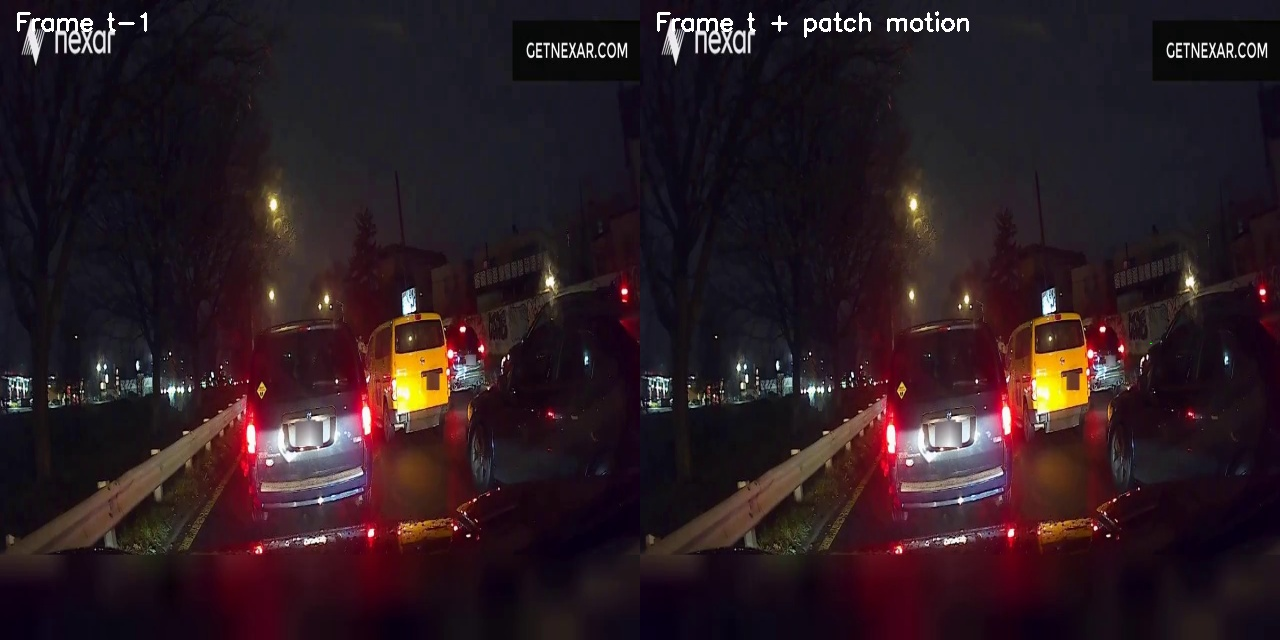

In [12]:
# Create one motion-arrow visualization
from IPython.display import Image as IPImage

if CREATE_VISUALIZATION and visualizations:
    name = sorted(visualizations)[0]
    vis = visualizations[name]

    prev_bgr = cv2.cvtColor(vis["previous_frame"], cv2.COLOR_RGB2BGR)
    curr_bgr = cv2.cvtColor(vis["current_frame"], cv2.COLOR_RGB2BGR)
    arrows = curr_bgr.copy()
    pf = vis["patch_flow"]

    for r in range(0, GRID_SIZE, ARROW_STEP):
        for c in range(0, GRID_SIZE, ARROW_STEP):
            dx, dy = map(float, pf[r, c])
            x = c * PATCH_SIZE + PATCH_SIZE // 2
            y = r * PATCH_SIZE + PATCH_SIZE // 2
            if abs(dx) < 0.5 and abs(dy) < 0.5:
                continue
            cv2.arrowedLine(
                arrows, (x, y),
                (int(round(x + dx)), int(round(y + dy))),
                (0, 255, 0), 1, tipLength=0.25
            )

    cv2.putText(prev_bgr, "Frame t-1", (15, 30),
                cv2.FONT_HERSHEY_SIMPLEX, 0.8, (255,255,255), 2)
    cv2.putText(arrows, "Frame t + patch motion", (15, 30),
                cv2.FONT_HERSHEY_SIMPLEX, 0.8, (255,255,255), 2)

    side = np.concatenate([prev_bgr, arrows], axis=1)
    vis_path = OUTPUT_DIR / f"stage5_motion_visualization_{Path(name).stem}.jpg"
    cv2.imwrite(str(vis_path), side)

    print("Visualization saved:", vis_path)
    display(IPImage(filename=str(vis_path)))

## Next stage

The saved `stage5_patch_motion_vectors.npz` contains one `[dx, dy]` motion vector per DINOv2 patch for every consecutive 5-FPS pair.

Stage 5B will use these vectors to compare:

- **same-position matching:** `(r,c) → (r,c)`
- **motion-compensated matching:** `(r,c) → (r+Δr,c+Δc)`

Then we will measure token cosine similarity and investigate a dynamic reuse threshold.

This stage alone does **not** claim computation reduction or downstream accuracy preservation.

In [13]:
import os
import zipfile
from pathlib import Path

# ================================================================
# CREATE DOWNLOADABLE STAGE 5A ZIP
# ================================================================

MOTION_DIR = Path("/kaggle/working/nexar_stage5/motion")
ZIP_PATH = Path("/kaggle/working/Stage5A_Motion_Results.zip")

# Files needed for Stage 5B + reporting
FILES_TO_ZIP = [
    "stage5_patch_motion_vectors.npz",   # ⭐ Most important
    "stage5_motion_summary.csv",         # Pair-level results
    "stage5_motion_per_video.csv",       # Per-video summary
    "stage5_motion_summary.json",        # Overall statistics
    "stage5_motion_config.json",         # Experiment configuration
]

# Add visualization(s), if present
visualizations = list(
    MOTION_DIR.glob("stage5_motion_visualization*.jpg")
)

for viz in visualizations:
    FILES_TO_ZIP.append(viz.name)

print("Files to include:")
print("=" * 60)

missing = []

for filename in FILES_TO_ZIP:
    path = MOTION_DIR / filename

    if path.exists():
        size_mb = path.stat().st_size / (1024 ** 2)
        print(f"✓ {filename:50s} {size_mb:.2f} MB")
    else:
        print(f"✗ MISSING: {filename}")
        missing.append(filename)

if missing:
    raise FileNotFoundError(
        "The following expected files are missing:\n" +
        "\n".join(missing)
    )

# Create ZIP
with zipfile.ZipFile(
    ZIP_PATH,
    "w",
    compression=zipfile.ZIP_DEFLATED
) as zf:

    for filename in FILES_TO_ZIP:
        source = MOTION_DIR / filename

        # Keep everything inside a clean "Stage5A_Motion_Results/" folder
        archive_name = f"Stage5A_Motion_Results/{filename}"

        zf.write(
            source,
            arcname=archive_name
        )

print("\n" + "=" * 60)
print("ZIP CREATED SUCCESSFULLY")
print("=" * 60)

zip_size_mb = ZIP_PATH.stat().st_size / (1024 ** 2)

print("File:", ZIP_PATH)
print(f"Size: {zip_size_mb:.2f} MB")

print("\nDownload this file from the Kaggle Output panel:")
print("Stage5A_Motion_Results.zip")

Files to include:
✓ stage5_patch_motion_vectors.npz                    10.11 MB
✓ stage5_motion_summary.csv                          0.11 MB
✓ stage5_motion_per_video.csv                        0.00 MB
✓ stage5_motion_summary.json                         0.00 MB
✓ stage5_motion_config.json                          0.00 MB
✓ stage5_motion_visualization_01040.jpg              0.18 MB

ZIP CREATED SUCCESSFULLY
File: /kaggle/working/Stage5A_Motion_Results.zip
Size: 10.33 MB

Download this file from the Kaggle Output panel:
Stage5A_Motion_Results.zip
